In [1]:
%load_ext autoreload
%autoreload 2

import deepxde as dde
import numpy as np
from config import X_MIN_BURGERS, X_MAX_BURGERS, T_BURGERS, NU_BURGERS, CURRICULUM_LEARNING, RAD, NU_PREV

dde.config.set_default_float("float64")

# Generación del dominio (no hay puntos)
geom = dde.geometry.Interval(X_MIN_BURGERS, X_MAX_BURGERS)   # Parte espacial
timedomain = dde.geometry.TimeDomain(0, T_BURGERS)           # Parte temporal
geomtime = dde.geometry.GeometryXTime(geom, timedomain)      # Dominio espaciotemporal

def pde_burgers(x, u):
    """
    Residuo de la ecuación de Burgers: u_t + u*u_x - nu*u_xx = 0
    x: tensor con las coordenadas (columna 0 = posición espacial, columna 1 = tiempo)
    u: salida de la red evaluada en esos puntos
    """
    u_t = dde.grad.jacobian(u, x, i=0, j=1)     # i: columna de la salida "u"
    u_x = dde.grad.jacobian(u, x, i=0, j=0)     # derivada primera espacial (término nuevo)
    u_xx = dde.grad.hessian(u, x, i=0, j=0)     # derivada segunda espacial
    return u_t + u * u_x - NU_BURGERS * u_xx

def condicion_inicial_burgers(x):
    return -np.sin(np.pi * x[:, 0:1])

# La condición inicial completa
ic = dde.icbc.IC(
    geomtime,
    condicion_inicial_burgers,
    lambda x, on_initial: on_initial
)

# Condiciones de contorno periódicas (idénticas a las del Calor)
bc_valores = dde.icbc.PeriodicBC(
    geomtime,
    component_x=0,
    component=0,
    on_boundary=lambda x, on_boundary: on_boundary
)

bc_derivadas = dde.icbc.PeriodicBC(
    geomtime,
    component_x=0,
    component=0,
    on_boundary=lambda x, on_boundary: on_boundary,
    derivative_order=1
)

# Juntar los datos del problema
data = dde.data.TimePDE(
    geomtime,
    pde_burgers,
    [ic, bc_valores, bc_derivadas],
    num_domain=20000,
    num_initial=1000,
    num_boundary=400
)

# Red neuronal
capas = [2] + [50] * 4 + [1]
activacion = "silu"
inicializador = "Glorot uniform"

red = dde.nn.FNN(capas, activacion, inicializador)

# Indicar que la red va a ser entrenada con "data"
model = dde.Model(data, red)
print(NU_BURGERS)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Set the default float type to float64
0.001


In [2]:
# Primera fase del entrenamiento de la red con optimizador Adam
import torch

model.compile("adam", lr=1e-3)

if CURRICULUM_LEARNING == True:
    checkpoint = torch.load(f"pinn_burgers_pesos_nu{NU_PREV}.pt", weights_only=True)
    model.net.load_state_dict(checkpoint["model_state_dict"])
    print("Pesos de nu=0.05 cargados correctamente")

if RAD == True:
    resampler = dde.callbacks.PDEPointResampler(period=1000)
    losshistory, train_state = model.train(iterations=30000, callbacks=[resampler])
else:
    losshistory, train_state = model.train(iterations=15000)

Compiling model...
'compile' took 2.427293 s

Pesos de nu=0.05 cargados correctamente
Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [2.74e+00, 5.72e-07, 2.52e-08, 8.94e-09]    [2.74e+00, 5.72e-07, 2.52e-08, 8.94e-09]    []  


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [3.06e-02, 4.25e-02, 7.65e-05, 8.90e-05]    [3.06e-02, 4.25e-02, 7.65e-05, 8.90e-05]    []  
2000      [2.50e-02, 2.71e-02, 6.35e-04, 1.85e-04]    [2.50e-02, 2.71e-02, 6.35e-04, 1.85e-04]    []  
3000      [1.38e-02, 1.92e-02, 1.19e-03, 2.45e-04]    [1.38e-02, 1.92e-02, 1.19e-03, 2.45e-04]    []  
4000      [2.45e-02, 9.04e-03, 2.32e-02, 1.79e-02]    [2.45e-02, 9.04e-03, 2.32e-02, 1.79e-02]    []  
5000      [1.03e-02, 6.29e-03, 1.43e-03, 1.14e-04]    [1.03e-02, 6.29e-03, 1.43e-03, 1.14e-04]    []  
6000      [4.98e-02, 4.01e-03, 1.17e-02, 8.40e-03]    [4.98e-02, 4.01e-03, 1.17e-02, 8.40e-03]    []  
7000      [3.01e-03, 3.41e-03, 5.64e-05, 2.71e-05]    [3.01e-03, 3.41e-03, 5.64e-05, 2.71e-05]    []  
8000      [2.53e-03, 2.19e-03, 8.10e-05, 1.29e-04]    [2.53e-03, 2.19e-03, 8.10e-05, 1.29e-04]    []  
9000      [4.63e-03, 1.84e-03, 1.49e-05, 1.41e-04]    [4.63e-03, 1.84e-03, 1.49e-05, 1.41e-04]    []  
10000     [2.16e-02, 1.25e-03, 4.60e-04, 1.57e-03]    [2.16e-02, 1.25e-03

In [3]:
# Segunda fase del entrenamiento de la red con optimizador L-BFGS
dde.optimizers.config.set_LBFGS_options(maxiter=15000, ftol=1e-14, gtol=1e-12)

model.compile("L-BFGS")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.000624 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
30000     [7.16e-04, 4.02e-04, 1.84e-04, 5.99e-06]    [7.16e-04, 4.02e-04, 1.84e-04, 5.99e-06]    []  
31000     [1.76e-04, 2.24e-04, 1.87e-07, 6.20e-07]    [1.76e-04, 2.24e-04, 1.87e-07, 6.20e-07]    []  
32000     [1.31e-04, 1.75e-04, 1.16e-07, 1.35e-07]    [1.32e-04, 1.75e-04, 1.16e-07, 1.35e-07]    []  
33000     [1.01e-04, 1.23e-04, 2.90e-07, 5.34e-07]    [1.01e-04, 1.23e-04, 2.90e-07, 5.34e-07]    []  
34000     [7.48e-05, 1.05e-04, 1.38e-07, 3.43e-07]    [7.49e-05, 1.05e-04, 1.38e-07, 3.43e-07]    []  
35000     [6.64e-05, 8.53e-05, 1.31e-07, 7.75e-08]    [6.64e-05, 8.53e-05, 1.31e-07, 7.75e-08]    []  
36000     [5.65e-05, 7.46e-05, 1.07e-07, 1.78e-07]    [5.65e-05, 7.46e-05, 1.07e-07, 1.78e-07]    []  
37000     [4.84e-05, 6.86e-05, 1.41e-07, 8.45e-08]    [4.83e-05, 6.86e-05, 1.41e-07, 8.45e-08]    []  
3

Error L2 relativo (PINN vs referencia FDM fina): 0.06046983709352267


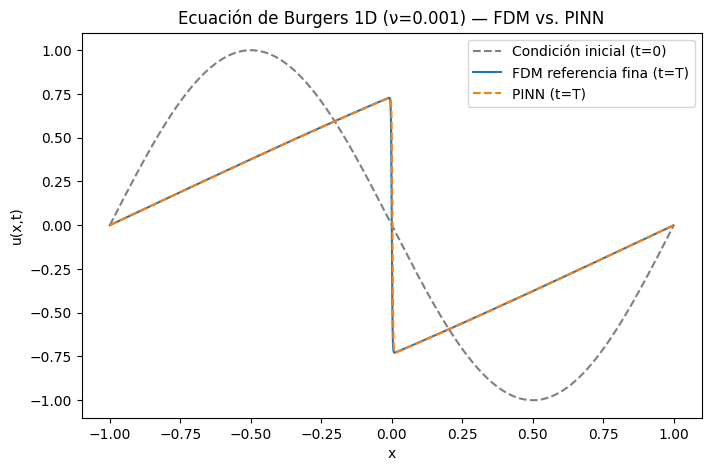

In [4]:
import matplotlib.pyplot as plt

# Cargar la referencia FDM de malla fina para el nu que toque
datos_ligeros = np.load('burgers_referencias_ultimo_t.npz')
x_ref = datos_ligeros[f'x_ref_nu{NU_BURGERS}']
u_ref_final = datos_ligeros[f'u_ref_nu{NU_BURGERS}']

# Evaluar la PINN en esos mismos puntos x, en t=T
t_eval = np.full_like(x_ref, T_BURGERS)
puntos_eval = np.vstack((x_ref, t_eval)).T
u_pinn = model.predict(puntos_eval).flatten()

# Error L2 (contra la referencia fina, no hay analítica en Burgers)
error_l2_pinn = np.linalg.norm(u_pinn - u_ref_final) / np.linalg.norm(u_ref_final)
print("Error L2 relativo (PINN vs referencia FDM fina):", error_l2_pinn)

# Condición inicial, para contexto visual
u0 = -np.sin(np.pi * x_ref)

# Gráfica comparativa
plt.figure(figsize=(8, 5))
plt.plot(x_ref, u0, '--', label='Condición inicial (t=0)', color='gray')
plt.plot(x_ref, u_ref_final, '-', label='FDM referencia fina (t=T)')
plt.plot(x_ref, u_pinn, '--', label='PINN (t=T)', markersize=3)
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title(f'Ecuación de Burgers 1D (ν={NU_BURGERS}) — FDM vs. PINN')
plt.show()

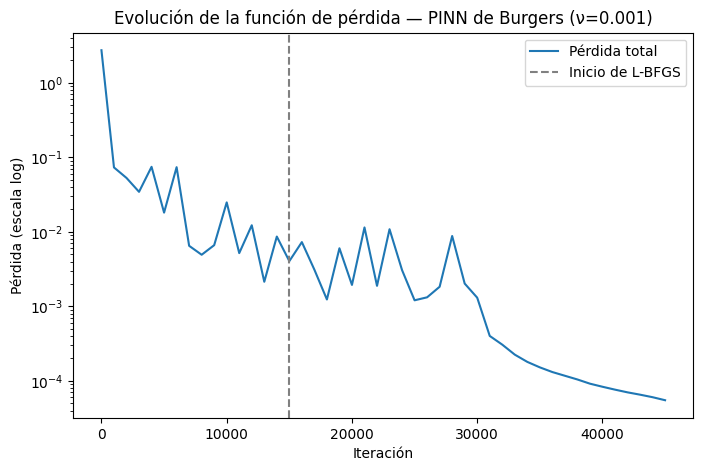

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Suma de los 4 términos de loss
loss_total = np.sum(losshistory.loss_train, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(losshistory.steps, loss_total, label='Pérdida total')
plt.axvline(x=15000, color='gray', linestyle='--', label='Inicio de L-BFGS')
plt.yscale('log')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (escala log)')
plt.legend()
plt.title(f'Evolución de la función de pérdida — PINN de Burgers (ν={NU_BURGERS})')
plt.show()

In [6]:
# Guardado
if True:
    np.savez(f'burgers_pinn_resultado_nu{NU_BURGERS}_mejorado_v2.npz', x=x_ref, u_pinn=u_pinn, error_l2_pinn=error_l2_pinn, loss_steps=losshistory.steps,
            loss_total=np.sum(losshistory.loss_train, axis=1))
    model.save(f"pinn_burgers_pesos_nu{NU_BURGERS}")
    print("Guardado bien v2")

Guardado bien v2
